<a href="https://colab.research.google.com/github/gnn59lll-coder/Laboratory-works-for-II/blob/main/%D0%9B%D0%B0%D0%B1%D0%B0_6_%D0%9D%D0%B5%D1%81%D0%B1%D0%B0%D0%BB%D0%B0%D0%BD%D1%81%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%BD%D1%8B%D0%B9_%D0%BD%D0%B0%D0%B1%D0%BE%D1%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Несбалансированный набор

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
das = pd.read_csv('/content/sample_data/data_about_students.csv', sep=';')
das.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
das.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [4]:
das.isnull().sum()

,0
Marital status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [5]:
das.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [7]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder()
das[['Target']] = enc.fit_transform(das[['Target']])
das.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0.0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2.0
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0.0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2.0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2.0


In [9]:
print('Отчисленные составляют', round(das['Target'].value_counts()[0]/len(das) * 100,2), '% данных')
print('Учащиеся составляют', round(das['Target'].value_counts()[1]/len(das) * 100,2), '% данных')
print('Выпустившиеся составляют', round(das['Target'].value_counts()[2]/len(das) * 100,2), '% данных')

Отчисленные составляют 32.12 % данных
Учащиеся составляют 17.95 % данных
Выпустившиеся составляют 49.93 % данных


Text(0.5, 1.0, 'Распределение классов \n (0: Отчисленный || 1: Учащийся || 2: Выпустившийся)')

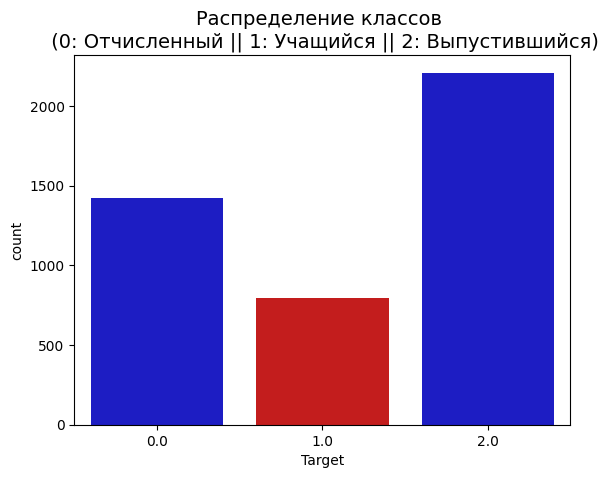

In [10]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Target', data=das, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0: Отчисленный || 1: Учащийся || 2: Выпустившийся)', fontsize=14)

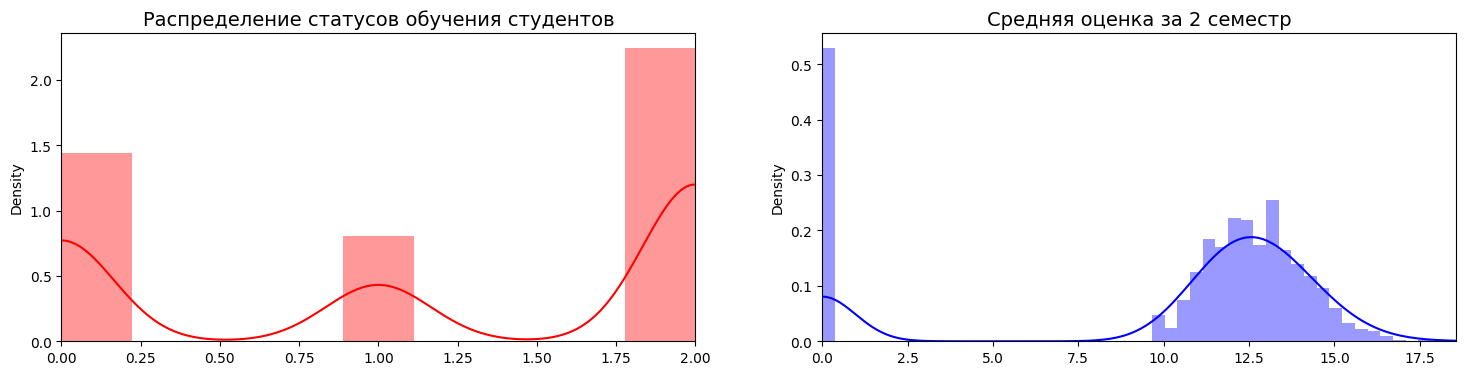

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

age_val = das['Target'].values
mag_val = das['Curricular units 2nd sem (grade)'].values

# строим график распределения статусов обучения студентов
sns.distplot(age_val, ax=ax[0], color='r')
ax[0].set_title('Распределение статусов обучения студентов', fontsize=14)
ax[0].set_xlim([min(age_val), max(age_val)])


# строим график распределения средних оценок студентов за 2 семестр
sns.distplot(mag_val, ax=ax[1], color='b')
ax[1].set_title('Средняя оценка за 2 семестр', fontsize=14)
ax[1].set_xlim([min(mag_val), max(mag_val)])

plt.show()

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import numpy as np
import pandas as pd

# 1. Разделяем признаки и целевую переменную
X = das.drop('Target', axis=1)
y = das['Target']

# 2. Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Выбираем столбцы для масштабирования
cols_to_scale = [col for col in X_train.columns]

rob_scaler = RobustScaler()

# 4. Масштабируем ТОЛЬКО признаки.
X_train[cols_to_scale] = rob_scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = rob_scaler.transform(X_test[cols_to_scale])

# 5. Преобразуем в numpy-массивы
original_Xtrain = X_train.values
original_Xtest = X_test.values
original_ytrain = y_train.values
original_ytest = y_test.values

# 6. Проверяем распределение классов
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label / len(original_ytrain))
print("Тестовый набор:", test_counts_label / len(original_ytest))

Распределение классов: 

Обучающий набор: [0.19610059 0.01695394 0.00028257 0.0008477  0.00254309 0.00536875
 0.00028257 0.00141283 0.00056513 0.00056513 0.0098898  0.00113026
 0.00169539 0.00678158 0.00056513 0.00028257 0.00452105 0.00254309
 0.00282566 0.00028257 0.00113026 0.00028257 0.00028257 0.03729867
 0.00028257 0.00028257 0.00056513 0.00028257 0.00028257 0.00113026
 0.00310822 0.00056513 0.00536875 0.00028257 0.01017237 0.00028257
 0.00113026 0.00028257 0.00028257 0.00028257 0.01356315 0.00028257
 0.00028257 0.00028257 0.00028257 0.00056513 0.00706414 0.00056513
 0.00141283 0.00028257 0.00028257 0.00028257 0.00028257 0.01864934
 0.00028257 0.00028257 0.00028257 0.00028257 0.00028257 0.00169539
 0.00028257 0.00028257 0.00028257 0.01017237 0.00028257 0.00056513
 0.00028257 0.00028257 0.00028257 0.00028257 0.01356315 0.00028257
 0.00028257 0.00028257 0.00028257 0.00028257 0.00141283 0.00028257
 0.00028257 0.00197796 0.00028257 0.00028257 0.00028257 0.00678158
 0.00056513 0.000282

In [30]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок

das = das.sample(frac=1)

fraud_das = das.loc[das['Target'] == 1]
non_fraud_das = das.loc[das['Target'] == 0][:4424]

normal_distributed_das = pd.concat([fraud_das, non_fraud_das])

# Перемешивание строк датасета
new_das = normal_distributed_das.sample(frac=1, random_state=42)

new_das.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
3185,1,17,2,9119,1,1,116.0,1,19,1,...,0,5,0,0,0.0,0,16.2,0.3,-0.92,0.0
2396,1,39,1,9003,1,1,140.0,1,1,3,...,0,6,10,0,0.0,0,16.2,0.3,-0.92,0.0
1786,2,39,1,9238,1,19,133.1,1,37,37,...,0,6,0,0,0.0,0,15.5,2.8,-4.06,0.0
745,2,43,1,9003,1,1,149.0,1,1,1,...,0,6,8,0,0.0,0,15.5,2.8,-4.06,0.0
3787,1,1,1,9238,1,1,116.0,1,38,38,...,0,6,12,0,0.0,0,11.1,0.6,2.02,0.0


In [17]:
new_das.shape

(2215, 37)

Распределение классов в подвыборке
Curricular units 2nd sem (grade)
0.0    1.0
Name: count, dtype: float64


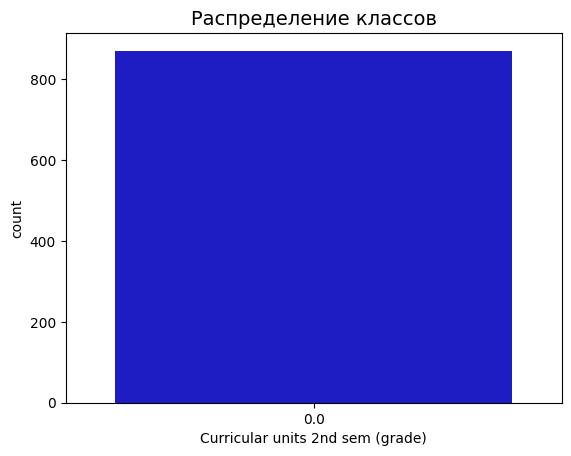

In [31]:
print('Распределение классов в подвыборке')
print(new_das['Target'].value_counts()/len(new_das))

# проверяем снова распределение целевой переменной
sns.countplot(x='Target', data = new_das, palette = colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

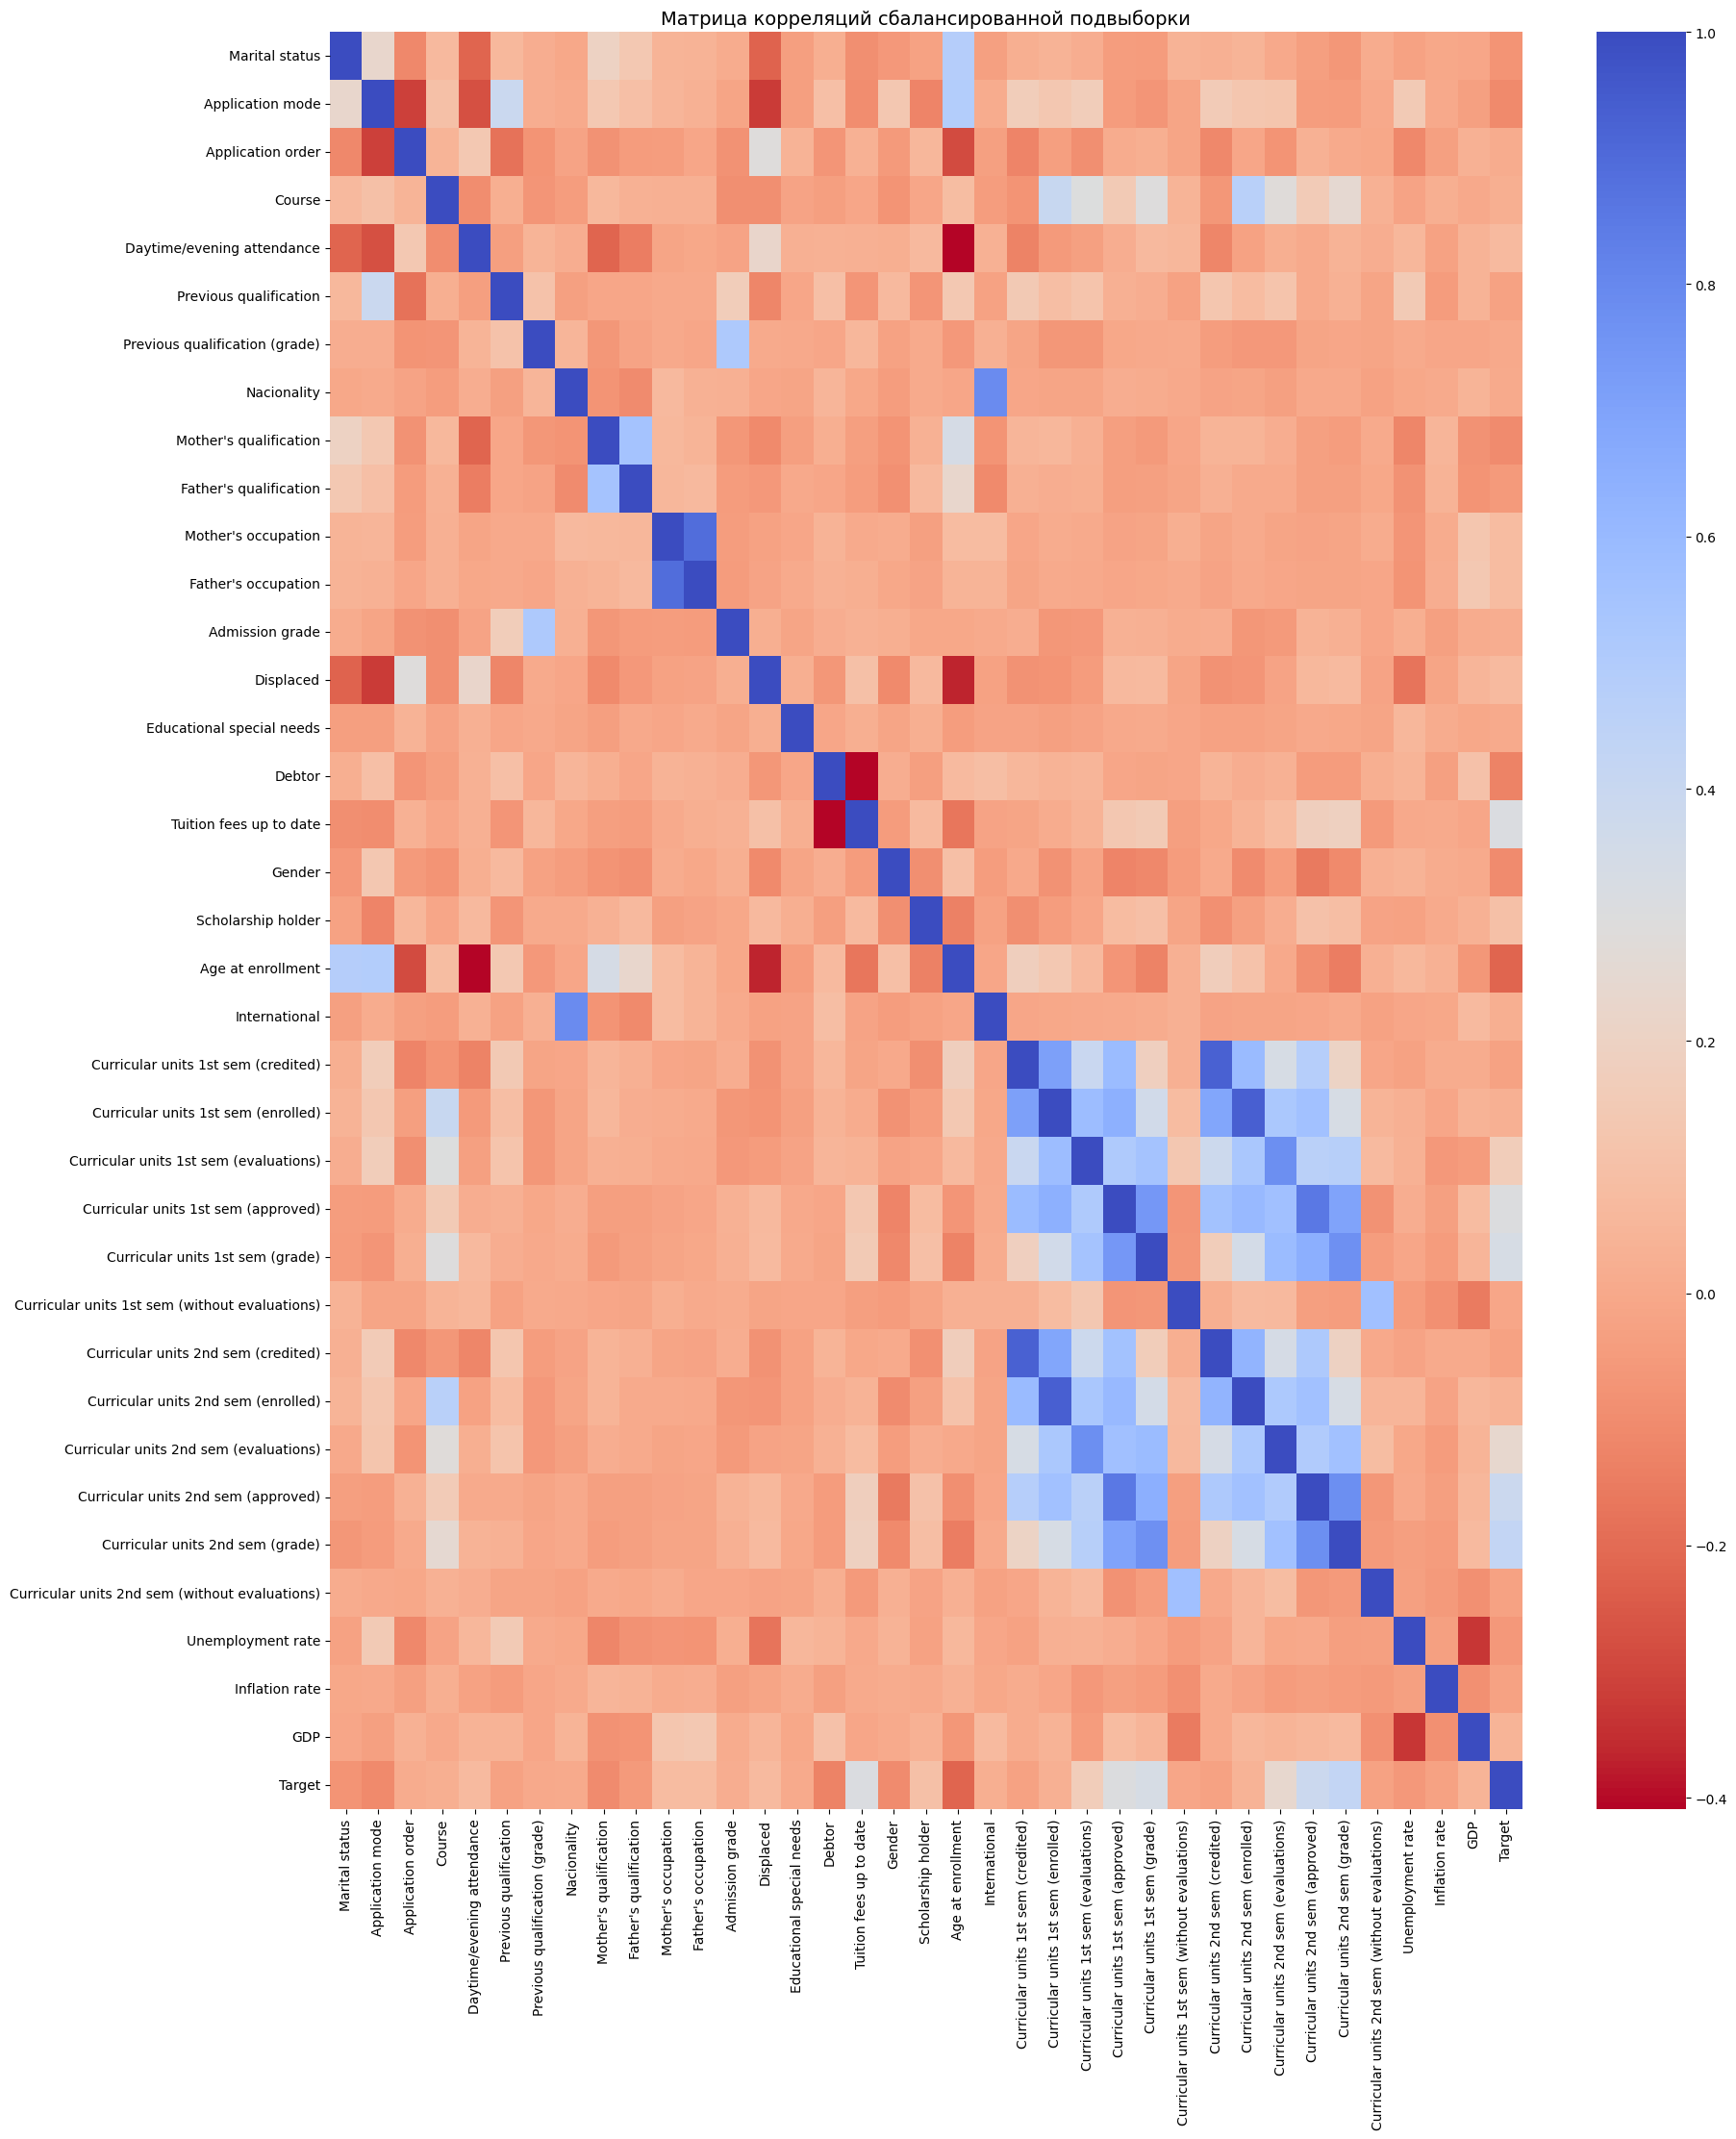

In [20]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = new_das.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

### Выводы:
<ul>
<li><b>Отрицательные корреляции: </b>Признаки 'Age at enrollment', 'International' имеют отрицательную корреляцию. Другими словами, чем ниже эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция. </li>
<li> <b> Положительные корреляции: </b> Признаки 'Unemployment rate', 'GDP' положительно коррелируют. То есть, чем выше эти значения, тем больше вероятность того, что конечным результатом будет мошенническая операция. </li>
</ul>

Построим теперь Boxplot.

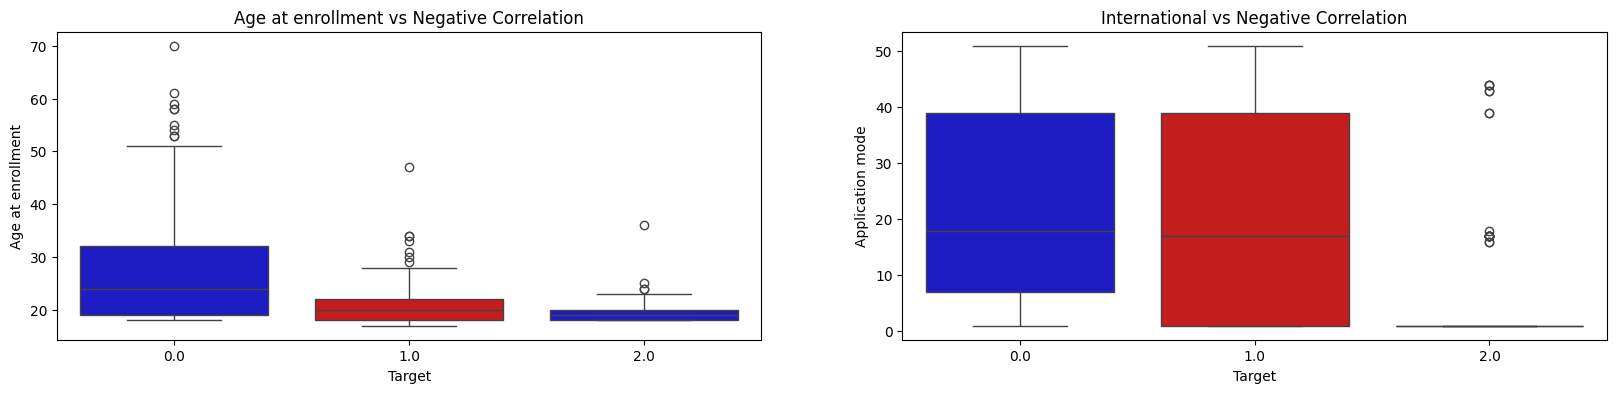

In [50]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))

sns.boxplot(x='Target', y='Age at enrollment', data=new_das, palette=colors, ax=axes[0])
axes[0].set_title('Age at enrollment vs Negative Correlation')

sns.boxplot(x='Target', y='Application mode', data=new_das, palette=colors, ax=axes[1])
axes[1].set_title('International vs Negative Correlation')

plt.show()

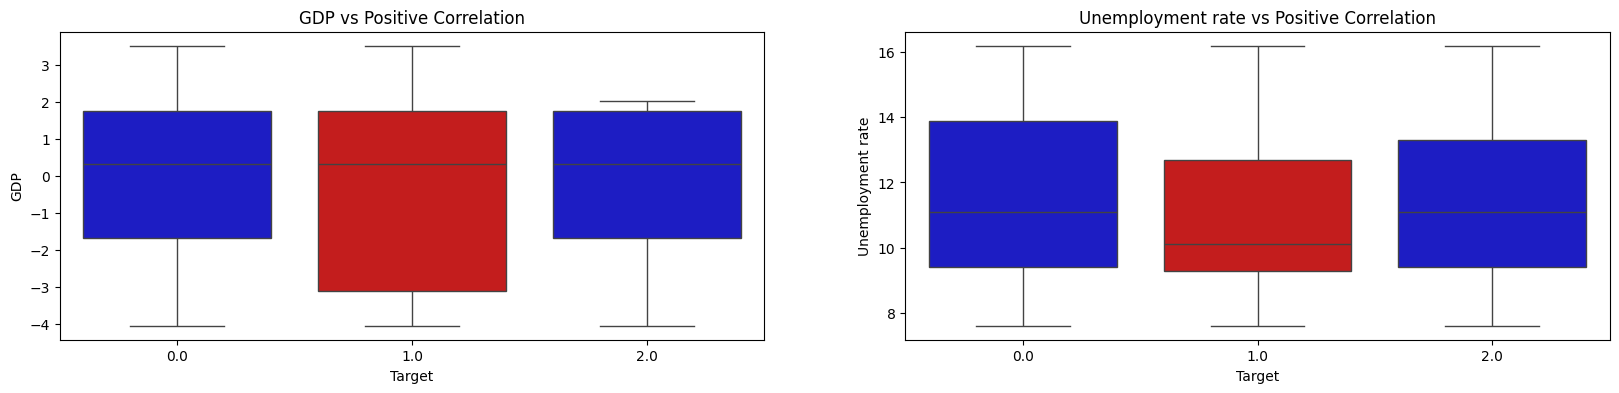

In [48]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))

sns.boxplot(x='Target', y='GDP', data=new_das, palette=colors, ax=axes[0])
axes[0].set_title('GDP vs Positive Correlation')

sns.boxplot(x='Target', y='Unemployment rate', data=new_das, palette=colors, ax=axes[1])
axes[1].set_title('Unemployment rate vs Positive Correlation')


plt.show()

## Обработка выбросов

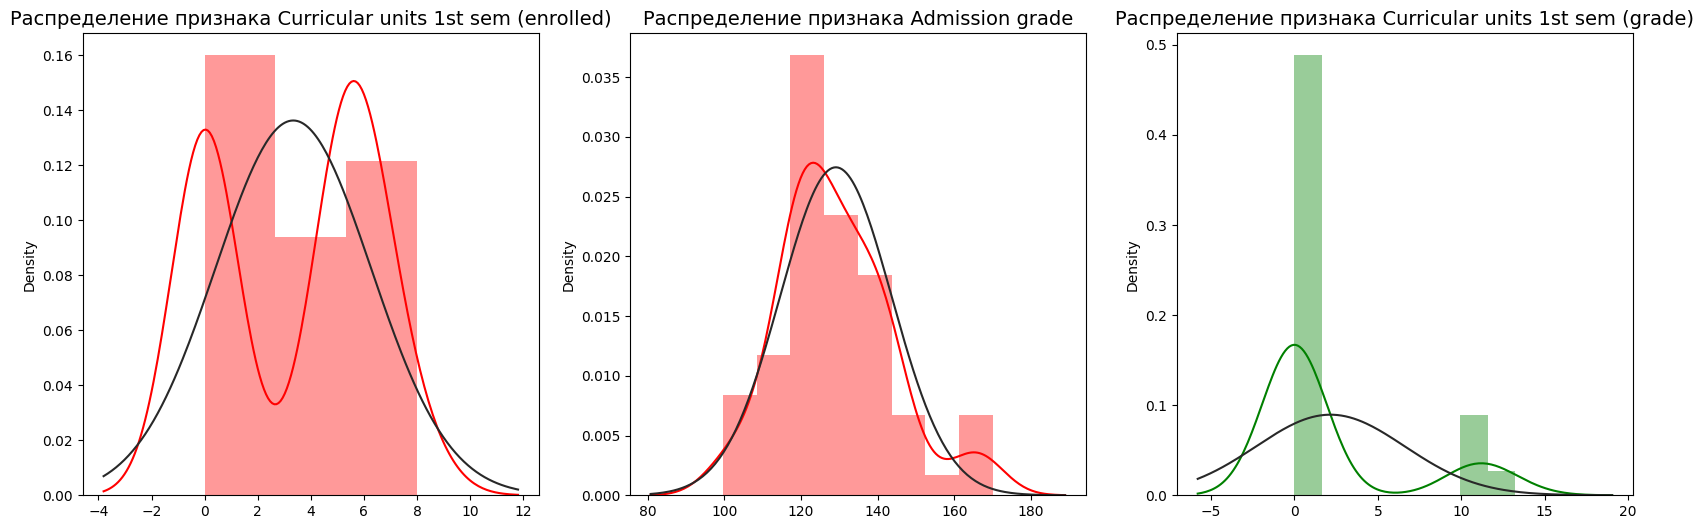

In [51]:
# Строим распределения для V14, V12, V10

from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(20, 6))

####
V10_fraud_dist = new_das['Curricular units 1st sem (enrolled)'].loc[new_das['Target'] == 1].values

sns.distplot(V10_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака Curricular units 1st sem (enrolled)', fontsize=14)

####
V12_fraud_dist = new_das['Admission grade'].loc[new_das['Target'] == 1].values

sns.distplot(V12_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака Admission grade', fontsize=14)

####
V14_fraud_dist = new_das['Curricular units 1st sem (grade)'].loc[new_das['Target'] == 1].values

sns.distplot(V14_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака Curricular units 1st sem (grade)', fontsize=14)

plt.show()

In [52]:
# Удаление выбросов из признака Curricular units 1st sem (enrolled)
V10_fraud = new_das['Curricular units 1st sem (enrolled)'].loc[new_das['Target'] == 1].values
q25, q75 = np.percentile(V10_fraud, 25), np.percentile(V10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
V10_iqr = q75 - q25
print('iqr: {}'.format(V10_iqr))

V10_cut_off = V10_iqr * 1.5
V10_lower, V10_upper = q25 - V10_cut_off, q75 + V10_cut_off
print('Порог: {}'.format(V10_cut_off))
print('V10 нижняя граница: {}'.format(V10_lower))
print('V10 верхняя граница: {}'.format(V10_upper))

outliers = [x for x in V10_fraud if x < V10_lower or x > V10_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_das_without_outliers  = new_das.drop(new_das[(new_das['Curricular units 1st sem (enrolled)'] > V10_upper) | (new_das['Curricular units 1st sem (enrolled)'] < V10_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака Admission grade
V12_fraud = new_das['Admission grade'].loc[new_das['Target'] == 1].values
q25, q75 = np.percentile(V12_fraud, 25), np.percentile(V12_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
V12_iqr = q75 - q25
print('iqr: {}'.format(V12_iqr))

V12_cut_off = V12_iqr * 1.5
V12_lower, V12_upper = q25 - V12_cut_off, q75 + V12_cut_off
print('Порог: {}'.format(V12_cut_off))
print('Admission grade нижняя граница: {}'.format(V12_lower))
print('Admission grade верхняя граница: {}'.format(V12_upper))

outliers = [x for x in V12_fraud if x < V12_lower or x > V12_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_das_without_outliers  = new_das.drop(new_das[(new_das['Admission grade'] > V12_upper) | (new_das['Admission grade'] < V12_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака Curricular units 1st sem (grade)
V14_fraud = new_das['Curricular units 1st sem (grade)'].loc[new_das['Target'] == 1].values
q25, q75 = np.percentile(V14_fraud, 25), np.percentile(V14_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
V14_iqr = q75 - q25
print('iqr: {}'.format(V14_iqr))

V14_cut_off = V14_iqr * 1.5
V14_lower, V14_upper = q25 - V14_cut_off, q75 + V14_cut_off
print('Порог: {}'.format(V14_cut_off))
print('Curricular units 1st sem (grade) нижняя граница: {}'.format(V14_lower))
print('Curricular units 1st sem (grade) верхняя граница: {}'.format(V14_upper))
outliers = [x for x in V14_fraud if x < V14_lower or x > V14_upper]
print('Количество выбросов: {}'.format(len(outliers)))
new_das_without_outliers  = new_das_without_outliers.drop(new_das_without_outliers[(new_das_without_outliers['Curricular units 1st sem (grade)'] > V14_upper) | (new_das_without_outliers['Curricular units 1st sem (grade)'] < V14_lower)].index)
print('----' * 44)


Квартиль 25: 0.0 | Квартиль 75: 6.0
iqr: 6.0
Порог: 9.0
V10 нижняя граница: -9.0
V10 верхняя граница: 15.0
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 120.0 | Квартиль 75: 138.375
iqr: 18.375
Порог: 27.5625
Admission grade нижняя граница: 92.4375
Admission grade верхняя граница: 165.9375
Количество выбросов: 2
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 0.0 | Квартиль 75: 0.0
iqr: 0.0
Порог: 0.0
Curricular units 1st sem (grade) нижняя граница: 0.0
Curricular units 1st sem (grade) верхняя граница: 0.0
Количество выбросов: 13
-----------------------------------------------------------------------------------------------------------------------------------------------------------

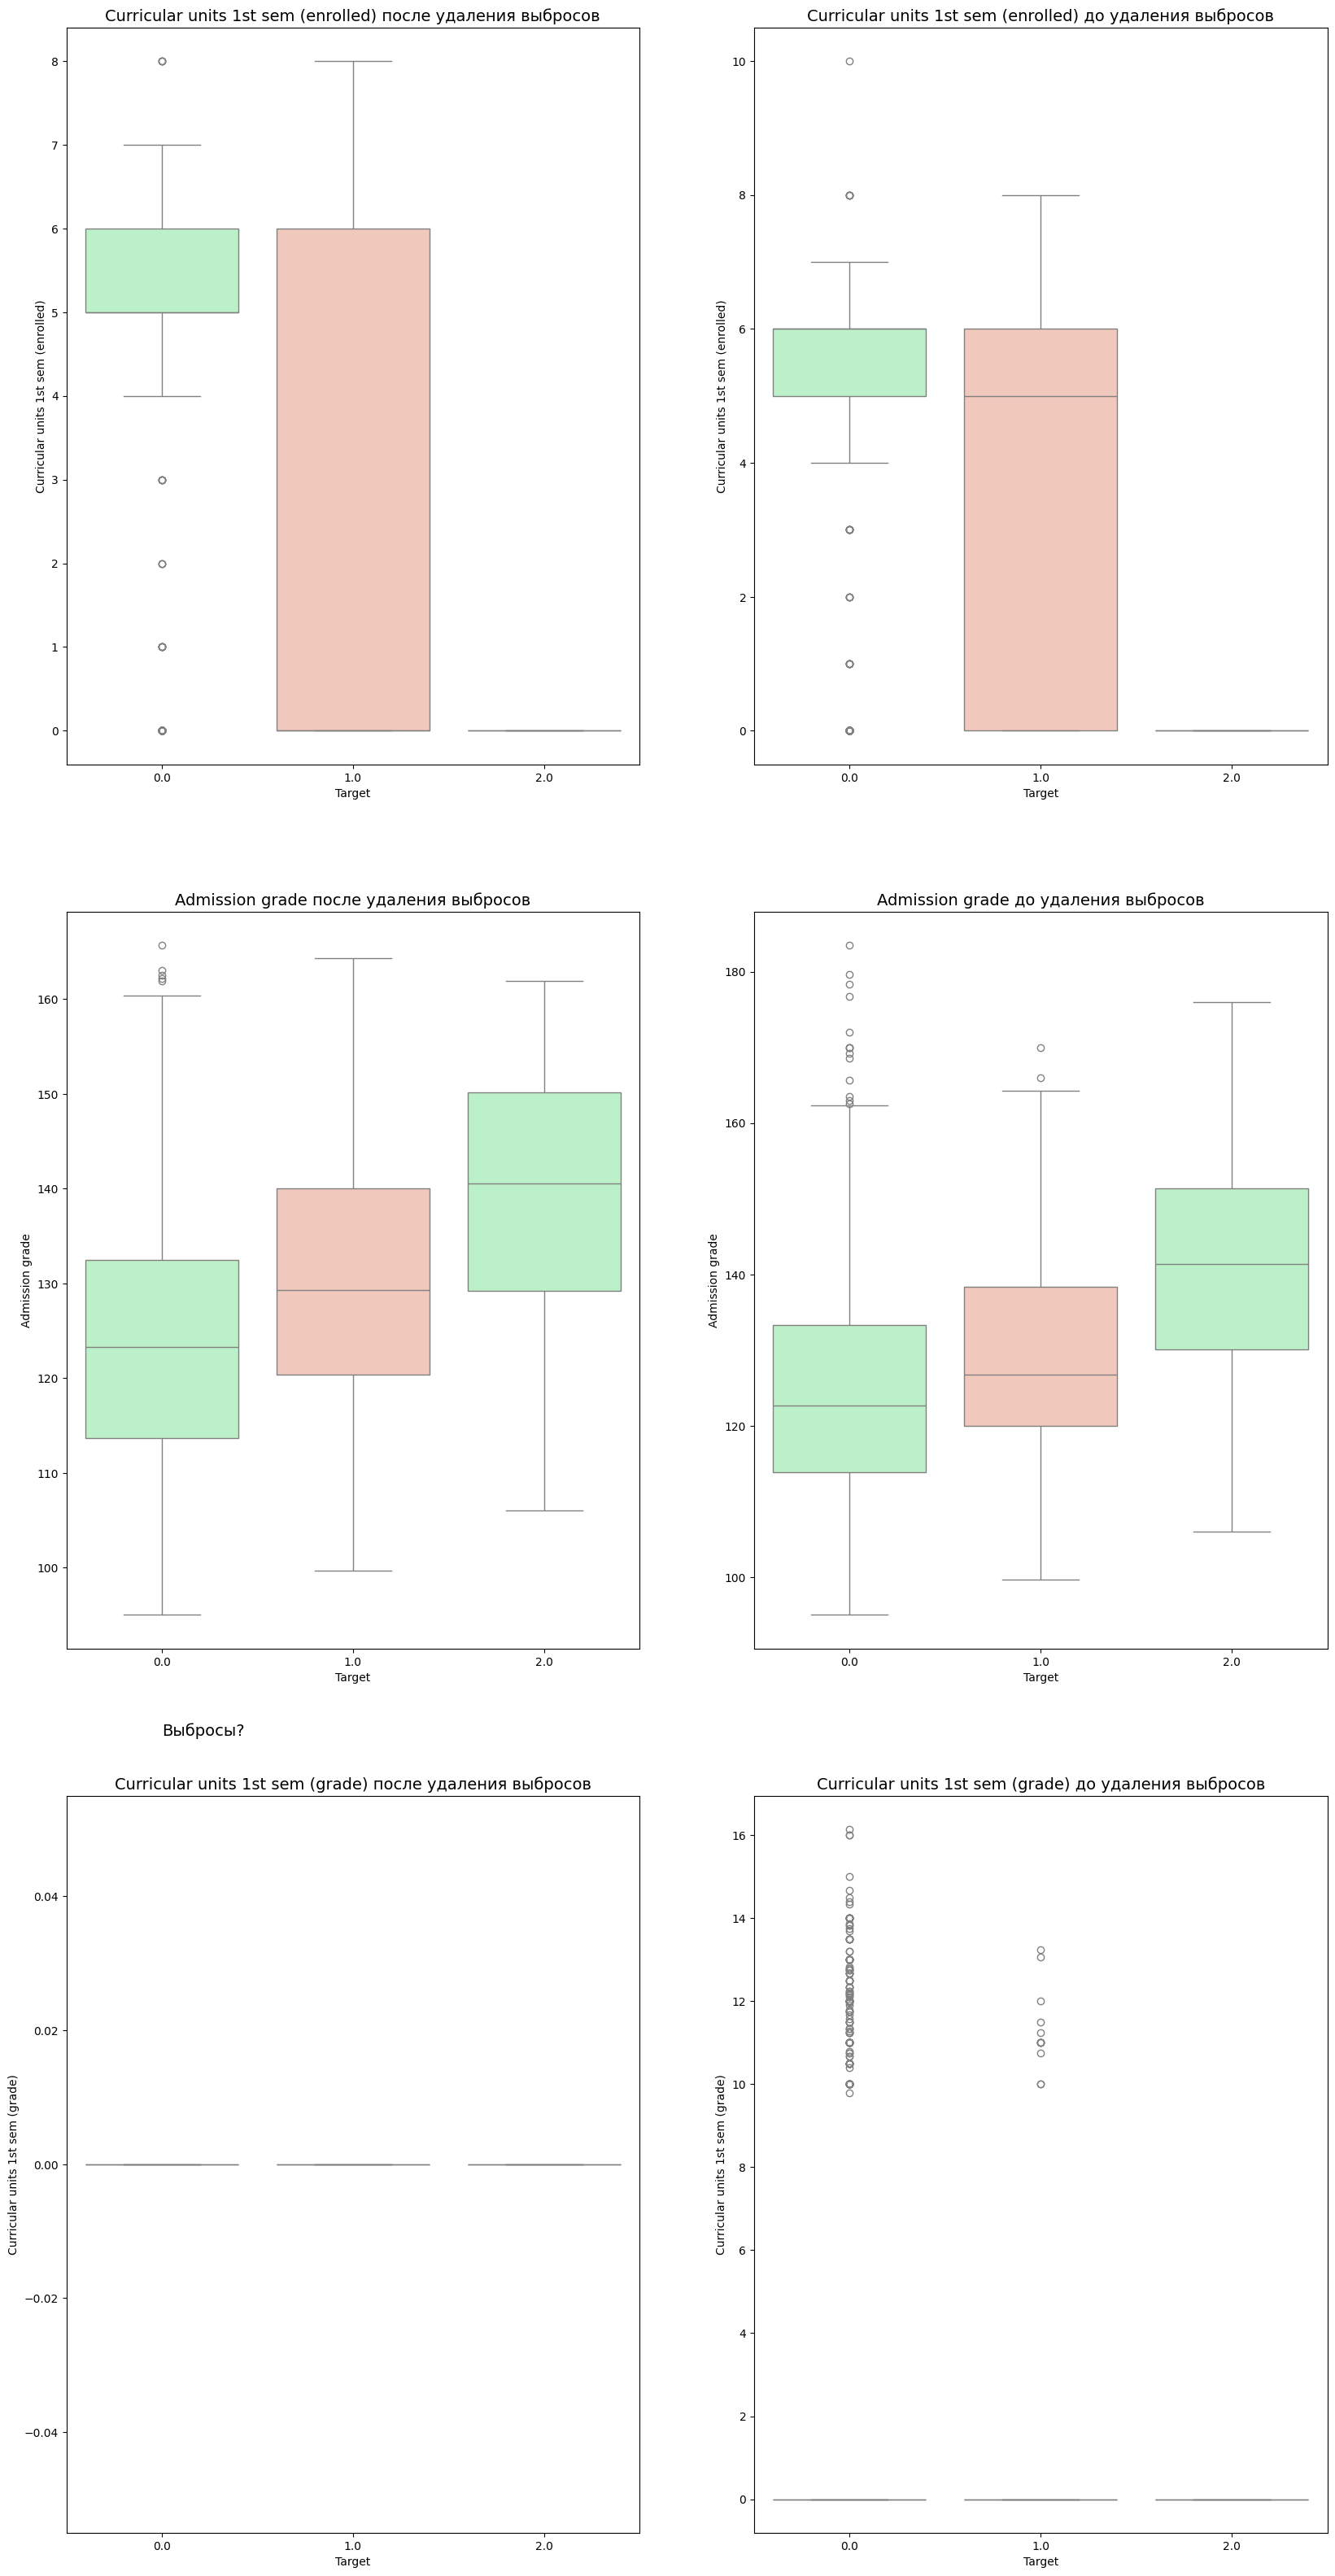

In [53]:
f, ax = plt.subplots(3, 2, figsize=(20,40))

colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака Curricular units 1st sem (enrolled)
sns.boxplot(x="Target", y="Curricular units 1st sem (enrolled)", data=new_das_without_outliers, ax=ax[0,0], palette=colors)
ax[0,0].set_title("Curricular units 1st sem (enrolled) после удаления выбросов", fontsize=14)
ax[0,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Curricular units 1st sem (enrolled)
sns.boxplot(x="Target", y="Curricular units 1st sem (enrolled)", data=new_das, ax=ax[0,1], palette=colors)
ax[0,1].set_title("Curricular units 1st sem (enrolled) до удаления выбросов", fontsize=14)
ax[0,1].annotate('Выбросы?', xy=(0.98, -17.5), xytext=(0, -12), fontsize=14)

# Boxplot для признака Admission grade
sns.boxplot(x="Target", y="Admission grade", data=new_das_without_outliers, ax=ax[1,0], palette=colors)
ax[1,0].set_title("Admission grade после удаления выбросов", fontsize=14)
ax[1,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Admission grade
sns.boxplot(x="Target", y="Admission grade", data=new_das, ax=ax[1,1], palette=colors)
ax[1,1].set_title("Admission grade до удаления выбросов", fontsize=14)
ax[1,1].annotate('Выбросы', xy=(0.98, -17.5), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

# Boxplot для признака Curricular units 1st sem (grade)
sns.boxplot(x="Target", y="Curricular units 1st sem (grade)", data=new_das_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("Curricular units 1st sem (grade) после удаления выбросов", fontsize=14)
ax[2,0].annotate('Выбросы?', xy=(0.9, 0.1), xytext=(0, -12), fontsize=14)

# Boxplot для признака Curricular units 1st sem (grade)
sns.boxplot(x="Target", y="Curricular units 1st sem (grade)", data=new_das, ax=ax[2,1], palette=colors)
ax[2,1].set_title("Curricular units 1st sem (grade) до удаления выбросов", fontsize=14)
ax[2,1].annotate('Выбросы', xy=(0.98, -17.3), xytext=(0, -12),
            arrowprops=dict(facecolor='black'), fontsize=14)

plt.show()

### Понижение размерности и кластеризация


In [54]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_das_without_outliers.drop('Target', axis=1)
y = new_das_without_outliers['Target']

# Удаляем International и Displaced, которые не коррелируют с таргетом
X.drop(['International', 'Displaced'], axis=1, inplace=True)

# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 7.4 сек
PCA заняло 0.037 сек
Truncated SVD заняло 0.014 сек


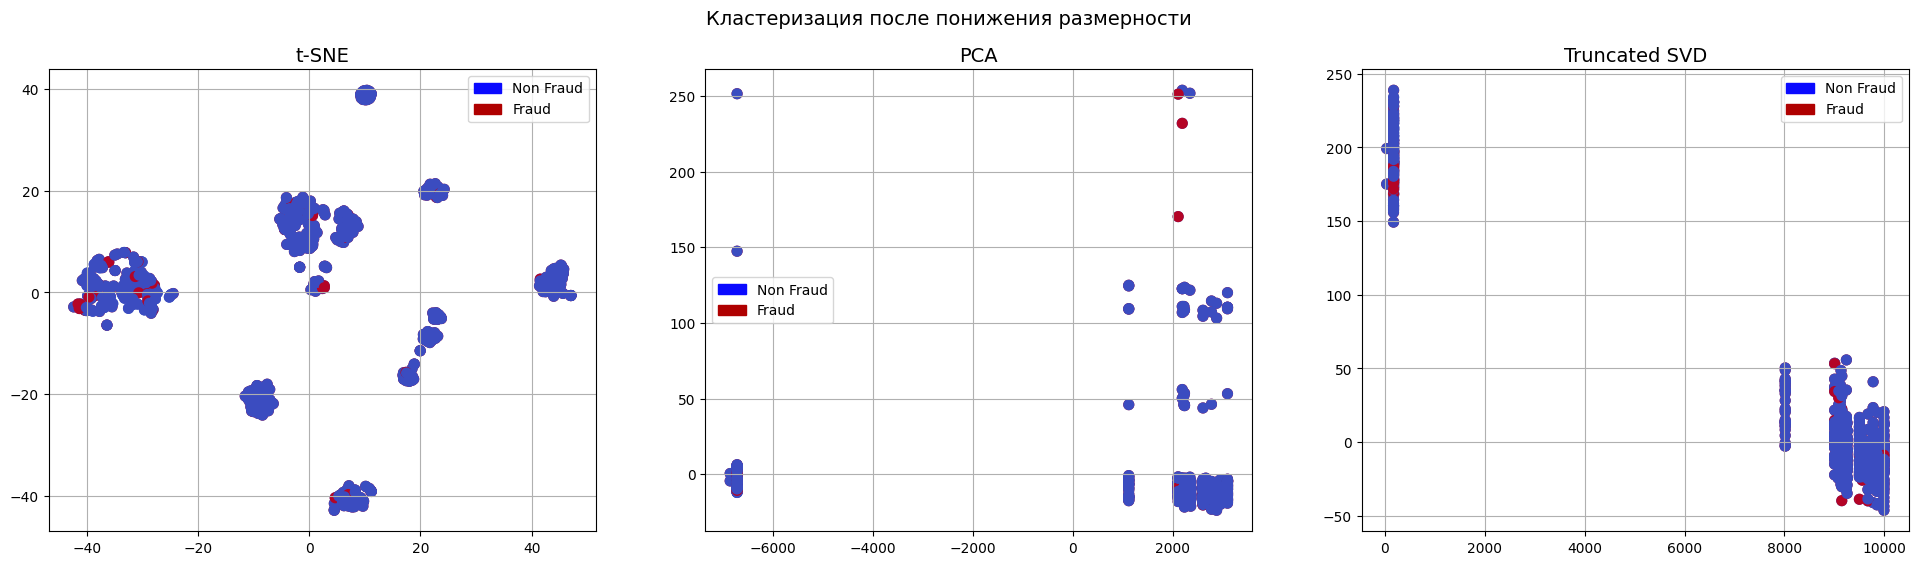

In [55]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Non Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()